# DeepLIFT/SHAP on Fine-tuned AlphaGenome (HepG2 MPRA)

Uses tangermeme's `deep_lift_shap` implementation on the full Encoder+Head model.

**Critical note on functional activations:**  
AlphaGenome uses *only* functional activations (`F.gelu`, `F.relu`, `F.softmax`,
`torch.sigmoid`, `torch.tanh`) — zero `nn.Module` nonlinearities. tangermeme's
hook-based DeepLIFT/SHAP can only intercept `nn.Module` subclasses, so the
rescale rule won't be applied to any of these operations.

We address this by:
1. Replacing the MPRAHead's functional activation with an `nn.Module` equivalent.
2. Monkey-patching the AlphaGenome encoder's forward methods to swap functional
   activations for module-based ones (so hooks can intercept them).
3. Checking convergence deltas to verify correctness.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [2]:
import sys
import json
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Add tangermeme from local clone (only needs numba as extra dep)
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'interp', 'tangermeme'))

from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.ersatz import dinucleotide_shuffle

from alphagenome_pytorch import AlphaGenome
from alphagenome_pytorch.extensions.finetuning.transfer import remove_all_heads
from alphagenome_pytorch.extensions.finetuning.utils import sequence_to_onehot

print(f'torch {torch.__version__}, CUDA available: {torch.cuda.is_available()}')

torch 2.10.0+cu128, CUDA available: True


## 1. Paths & config

In [3]:
MODEL_DIR = os.path.join(REPO_ROOT, 'training', 'results', 'WTC11_twostep_v4_do03')
CKPT_PATH = os.path.join(MODEL_DIR, 'checkpoints', 'best_stage2.pt')
WEIGHTS_PATH = os.path.join(REPO_ROOT, 'weights', 'model_fold_0.safetensors')
DATA_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/test_run_lenti_data'

with open(os.path.join(MODEL_DIR, 'args.json')) as f:
    args = json.load(f)
hp = args['hp']
print(json.dumps(hp, indent=2))

{
  "cell_type": "WTC11",
  "batch_size": 32,
  "num_epochs": 100,
  "learning_rate": 0.001,
  "weight_decay": 1e-06,
  "center_bp": 256,
  "pooling_type": "flatten",
  "nl_size": 1024,
  "dropout": 0.3,
  "activation": "relu",
  "early_stopping": 5,
  "random_shift": true,
  "random_shift_likelihood": 0.5,
  "reverse_complement": true,
  "sequence_length": 384,
  "val_eval_frequency": 4,
  "stage2_lr": 1e-05,
  "stage2_epochs": 50,
  "stage2_patience": 5
}


## 2. Define MPRAHead (module-based activation)

The training script uses `F.relu` / `F.gelu` (functional). We replace it with
`nn.ReLU()` / `nn.GELU()` so tangermeme can register hooks on it.

In [4]:
ENCODER_DIM = 1536
ENCODER_RESOLUTION_BP = 128


class MPRAHead(nn.Module):
    """MLP head with nn.Module-based activation for DeepLIFT/SHAP compatibility."""

    def __init__(self, n_positions, nl_size=1024, dropout=0.3,
                 activation='relu', pooling_type='flatten', center_bp=256):
        super().__init__()
        self.pooling_type = pooling_type
        self.center_bp = center_bp
        self.n_positions = n_positions
        self._center_window_positions = max(1, center_bp // ENCODER_RESOLUTION_BP)

        hidden_sizes = [nl_size] if isinstance(nl_size, int) else list(nl_size)
        self.norm = nn.LayerNorm(ENCODER_DIM)

        in_dim = n_positions * ENCODER_DIM if pooling_type == 'flatten' else ENCODER_DIM

        layers = []
        for hs in hidden_sizes:
            layers.append(nn.Linear(in_dim, hs))
            in_dim = hs
        self.hidden_layers = nn.ModuleList(layers)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.output = nn.Linear(in_dim, 1)

        # Module-based activation (critical for DeepLIFT/SHAP hooks)
        if activation == 'gelu':
            self.act = nn.GELU()
        else:
            self.act = nn.ReLU()

    def _pool(self, x):
        if self.pooling_type == 'flatten':
            return x.flatten(1)
        elif self.pooling_type == 'center':
            return x[:, x.shape[1] // 2, :]
        else:
            seq_len = x.shape[1]
            ws = min(self._center_window_positions, seq_len)
            cs = max(0, (seq_len - ws) // 2)
            center = x[:, cs:cs + ws, :]
            if self.pooling_type == 'mean':
                return center.mean(dim=1)
            elif self.pooling_type == 'max':
                return center.max(dim=1).values
            elif self.pooling_type == 'sum':
                return center.sum(dim=1)
            raise ValueError(f'Unknown pooling_type: {self.pooling_type}')

    def forward(self, encoder_output):
        x = self.norm(encoder_output)
        x = self._pool(x)
        for layer in self.hidden_layers:
            x = layer(x)
            x = self.dropout(x)
            x = self.act(x)
        x = self.output(x)
        return x.squeeze(-1)

## 3. Patch AlphaGenome encoder to use module-based activations

AlphaGenome's encoder uses functional activations everywhere:
- `layers.gelu()` (custom sigmoid-based GELU) in ConvBlock
- `F.relu()` in MLPBlock, PairMLPBlock
- `F.gelu()` in AttentionBiasBlock, SequenceToPairBlock  
- `torch.tanh()` in MHABlock (logit soft-capping)
- `F.softmax()` in MHABlock, RowAttentionBlock

We monkey-patch both `__init__` (to add module attributes) and `forward`
(to use them instead of functional calls).

In [5]:
import alphagenome_pytorch.layers as ag_layers
import alphagenome_pytorch.attention as ag_attn
from alphagenome_pytorch.convolutions import ConvBlock
from alphagenome_pytorch.model import SequenceEncoder
from alphagenome_pytorch.attention import apply_rope, _central_mask_features, _shift, _MAX_RELATIVE_DISTANCE


# =====================================================================
# Custom GELU module matching AlphaGenome's JAX-compat gelu
# =====================================================================
class AGCustomGELU(nn.Module):
    """Module version of alphagenome_pytorch.layers.gelu (sigmoid approx)."""
    def forward(self, x):
        return torch.sigmoid(1.702 * x) * x


# =====================================================================
# Pool1d: F.max_pool1d -> self._maxpool_module (nn.MaxPool1d)
# Original forward uses F.max_pool1d which is functional and can't be
# hooked by tangermeme. We replace it with nn.MaxPool1d module so the
# DeepLIFT rescale rule is applied to max pooling.
# =====================================================================
_orig_pool1d_init = ag_layers.Pool1d.__init__

def _patched_pool1d_init(self, *args, **kwargs):
    _orig_pool1d_init(self, *args, **kwargs)
    if self.method == 'max':
        self._maxpool_module = nn.MaxPool1d(
            kernel_size=self.kernel_size, stride=self.stride
        )

def _patched_pool1d_forward(self, x):
    input_size = x.shape[-1]
    output_size = (input_size + self.stride - 1) // self.stride
    pad_total = max((output_size - 1) * self.stride + self.kernel_size - input_size, 0)
    if pad_total > 0:
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        x = F.pad(x, (pad_left, pad_right))
    if self.method == 'max':
        return self._maxpool_module(x)
    elif self.method in ['avg', 'mean']:
        return F.avg_pool1d(x, kernel_size=self.kernel_size, stride=self.stride)
    else:
        raise NotImplementedError(f"Pooling method {self.method} not implemented")

ag_layers.Pool1d.__init__ = _patched_pool1d_init
ag_layers.Pool1d.forward = _patched_pool1d_forward


# =====================================================================
# SequenceEncoder: replace single shared self.pool with 7 separate
# Pool1d instances. tangermeme hooks save module.input/output per-module,
# so reusing one module for 7 calls causes shape mismatches in backward.
# =====================================================================
_orig_seqenc_init = SequenceEncoder.__init__

def _patched_seqenc_init(self):
    _orig_seqenc_init(self)
    # Replace the single shared pool with 7 independent Pool1d modules
    # (1 after embedder + 6 after each DownResBlock)
    del self.pool
    self.pools = nn.ModuleList([
        ag_layers.Pool1d(kernel_size=2) for _ in range(7)
    ])

def _patched_seqenc_forward(self, x):
    x = x.transpose(1, 2)  # (B, S, 4) -> (B, 4, S)
    intermediates = {}
    x = self.dna_embedder(x)
    intermediates['bin_size_1'] = x
    x = self.pools[0](x)

    for i, block in enumerate(self.down_blocks):
        if self.gradient_checkpointing and torch.is_grad_enabled():
            from torch.utils.checkpoint import checkpoint
            x = checkpoint(block, x, use_reentrant=False)
        else:
            x = block(x)
        bin_size = self.bin_sizes[i]
        intermediates[f'bin_size_{bin_size}'] = x
        x = self.pools[i + 1](x)

    return x, intermediates

SequenceEncoder.__init__ = _patched_seqenc_init
SequenceEncoder.forward = _patched_seqenc_forward


# =====================================================================
# ConvBlock: layers.gelu() -> self._gelu_module()
# Original forward: return self.conv(layers.gelu(self.norm(x)))
# =====================================================================
_orig_convblock_init = ConvBlock.__init__

def _patched_convblock_init(self, *args, **kwargs):
    _orig_convblock_init(self, *args, **kwargs)
    self._gelu_module = AGCustomGELU()

def _patched_convblock_forward(self, x):
    return self.conv(self._gelu_module(self.norm(x)))

ConvBlock.__init__ = _patched_convblock_init
ConvBlock.forward = _patched_convblock_forward


# =====================================================================
# MLPBlock: F.relu() -> self._relu_module()
# =====================================================================
_orig_mlpblock_init = ag_attn.MLPBlock.__init__

def _patched_mlpblock_init(self, *args, **kwargs):
    _orig_mlpblock_init(self, *args, **kwargs)
    self._relu_module = nn.ReLU()

def _patched_mlpblock_forward(self, x):
    h = self.norm(x)
    h = self._relu_module(self.fc1(h))
    h = self.fc2(h)
    return self.final_norm(h)

ag_attn.MLPBlock.__init__ = _patched_mlpblock_init
ag_attn.MLPBlock.forward = _patched_mlpblock_forward


# =====================================================================
# AttentionBiasBlock: F.gelu() -> self._gelu_module()
# =====================================================================
_orig_attnbias_init = ag_attn.AttentionBiasBlock.__init__

def _patched_attnbias_init(self, *args, **kwargs):
    _orig_attnbias_init(self, *args, **kwargs)
    self._gelu_module = nn.GELU()

def _patched_attnbias_forward(self, x):
    h = self._gelu_module(self.norm(x))
    h = self.proj(h)
    h = torch.repeat_interleave(h, 16, dim=1)
    h = torch.repeat_interleave(h, 16, dim=2)
    return h.permute(0, 3, 1, 2)

ag_attn.AttentionBiasBlock.__init__ = _patched_attnbias_init
ag_attn.AttentionBiasBlock.forward = _patched_attnbias_forward


# =====================================================================
# PairMLPBlock: F.relu() -> self._relu_module()
# =====================================================================
_orig_pairmlp_init = ag_attn.PairMLPBlock.__init__

def _patched_pairmlp_init(self, *args, **kwargs):
    _orig_pairmlp_init(self, *args, **kwargs)
    self._relu_module = nn.ReLU()

def _patched_pairmlp_forward(self, x):
    h = self.norm(x)
    h = self.linear1(h)
    h = self._relu_module(h)
    h = self.linear2(h)
    return h

ag_attn.PairMLPBlock.__init__ = _patched_pairmlp_init
ag_attn.PairMLPBlock.forward = _patched_pairmlp_forward


# =====================================================================
# MHABlock: torch.tanh() -> self._tanh_module()
#           F.softmax()   -> self._softmax_module()
# =====================================================================
_orig_mha_init = ag_attn.MHABlock.__init__

def _patched_mha_init(self, *args, **kwargs):
    _orig_mha_init(self, *args, **kwargs)
    self._tanh_module = nn.Tanh()
    self._softmax_module = nn.Softmax(dim=-1)

def _patched_mha_forward(self, x, attention_bias, compute_dtype=None):
    B, S, D = x.shape
    if compute_dtype is None:
        compute_dtype = x.dtype
    x = x.to(compute_dtype)

    h = self.norm(x)

    q = self.norm_q(self.q_proj(h).view(B, S, 8, 128))
    k = self.norm_k(self.k_proj(h).view(B, S, 1, 128))
    v = self.norm_v(self.v_proj(h).view(B, S, 1, 192))

    q = apply_rope(q, inplace=True)
    k = apply_rope(k, inplace=True)

    q_t = q.permute(0, 2, 1, 3)
    k_t = k.permute(0, 2, 1, 3)

    att = torch.matmul(q_t, k_t.transpose(-2, -1)).float()
    att = att / math.sqrt(128.0)

    if attention_bias is not None:
        att = att + attention_bias.float()

    logits_soft_cap = 5.0
    att = self._tanh_module(att / logits_soft_cap) * logits_soft_cap

    attn_weights = self._softmax_module(att)

    v_t = v.permute(0, 2, 1, 3)
    y = torch.matmul(attn_weights.to(compute_dtype), v_t).float()
    y = y.to(compute_dtype)
    y = y.permute(0, 2, 1, 3).reshape(B, S, -1)

    y = self.linear_embedding(y)
    return self.final_norm(y)

ag_attn.MHABlock.__init__ = _patched_mha_init
ag_attn.MHABlock.forward = _patched_mha_forward


# =====================================================================
# SequenceToPairBlock: F.gelu() -> self._gelu_module()
# =====================================================================
_orig_s2p_init = ag_attn.SequenceToPairBlock.__init__

def _patched_s2p_init(self, *args, **kwargs):
    _orig_s2p_init(self, *args, **kwargs)
    self._gelu_module = nn.GELU()

def _patched_s2p_forward(self, x):
    x_pooled = self.pool(x.transpose(1, 2)).transpose(1, 2)
    x_norm = self.norm_seq2pair(x_pooled)

    B, S_prime, _ = x_norm.shape

    q = self.linear_q(x_norm).view(B, S_prime, self.num_heads, self.head_dim)
    k = self.linear_k(x_norm).view(B, S_prime, self.num_heads, self.head_dim)

    range_vec = torch.arange(-S_prime, S_prime, device=x.device, dtype=torch.float32)
    pos_feat = _central_mask_features(torch.abs(range_vec), self.num_heads, _MAX_RELATIVE_DISTANCE // 16)
    sign = torch.sign(range_vec).unsqueeze(-1)
    pos_feat = torch.cat([pos_feat, sign * pos_feat], dim=-1)
    pos_feat = pos_feat.to(x.dtype)

    pos_encoding = self.linear_pos_features(pos_feat).view(2 * S_prime, self.num_heads, self.head_dim)

    term_q = torch.einsum('bqhc,phc->bhqp', q + self.q_r_bias, pos_encoding)
    term_k = torch.einsum('bkhc,phc->bhkp', k + self.k_r_bias, pos_encoding)

    rel_q_a = _shift(term_q, S_prime, S_prime)
    rel_k_a = _shift(term_k, S_prime, S_prime)

    rel_q_a = rel_q_a.permute(0, 2, 3, 1)
    rel_k_a = rel_k_a.permute(0, 3, 2, 1)

    a = torch.einsum('bqhc,bkhc->bqkh', q, k)
    a = a + 0.5 * (rel_q_a + rel_k_a)

    x_gelu = self._gelu_module(x_norm)
    y_q = self.linear_y_q(x_gelu)
    y_k = self.linear_y_k(x_gelu)

    pair_act = self.linear_pair(a) + y_q.unsqueeze(2) + y_k.unsqueeze(1)
    return pair_act

ag_attn.SequenceToPairBlock.__init__ = _patched_s2p_init
ag_attn.SequenceToPairBlock.forward = _patched_s2p_forward


# =====================================================================
# RowAttentionBlock: F.softmax() -> self._softmax_module()
# =====================================================================
_orig_rowattn_init = ag_attn.RowAttentionBlock.__init__

def _patched_rowattn_init(self, *args, **kwargs):
    _orig_rowattn_init(self, *args, **kwargs)
    self._softmax_module = nn.Softmax(dim=-1)

def _patched_rowattn_forward(self, x, compute_dtype=None):
    if compute_dtype is None:
        compute_dtype = x.dtype
    x = x.to(compute_dtype)

    h = self.norm(x)
    q = self.linear_q(h)
    k = self.linear_k(h)
    v = self.linear_v(h)

    scale = 1.0 / math.sqrt(128.0)
    attn = torch.einsum('bpqf,bpkf->bpqk', q, k).float() * scale
    attn = self._softmax_module(attn)

    out = torch.einsum('bpqk,bpkf->bpqf', attn.to(compute_dtype), v).float()
    return out.to(compute_dtype)

ag_attn.RowAttentionBlock.__init__ = _patched_rowattn_init
ag_attn.RowAttentionBlock.forward = _patched_rowattn_forward


print('All patches applied (init + forward), including Pool1d and SequenceEncoder.')

All patches applied (init + forward), including Pool1d and SequenceEncoder.


## 4. Load model

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load base AlphaGenome (patches are active, so modules will be created)
model = AlphaGenome.from_pretrained(WEIGHTS_PATH, device='cpu')
remove_all_heads(model)

# Build head with same hyperparameters
head = MPRAHead(
    n_positions=3,
    nl_size=hp['nl_size'],
    dropout=0.0,  # no dropout at inference
    activation=hp['activation'],
    pooling_type=hp['pooling_type'],
    center_bp=hp['center_bp'],
)

# Load fine-tuned weights
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
model.load_state_dict(ckpt['model_state_dict'], strict=False)
head.load_state_dict(ckpt['head_state_dict'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

Loaded checkpoint from epoch 4 (val_loss=0.3915)


## 5. Create end-to-end wrapper

In [7]:
class AlphaGenomeMPRA(nn.Module):
    """End-to-end wrapper: one-hot (B, 4, L) -> scalar MPRA prediction (B, 1)."""

    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, x):
        # tangermeme passes (B, 4, L) -- transpose to (B, L, 4) for AlphaGenome
        x = x.transpose(1, 2)
        org_idx = torch.zeros(x.shape[0], dtype=torch.long, device=x.device)
        enc_out = self.encoder(
            x, org_idx, encoder_only=True
        )['encoder_output'].transpose(1, 2)
        pred = self.head(enc_out)
        return pred.unsqueeze(-1)  # (B, 1) as tangermeme expects


wrapped_model = AlphaGenomeMPRA(model, head)
wrapped_model = wrapped_model.to(device).eval()
print('Wrapped model ready.')

Wrapped model ready.


## 6. Verify hookable nonlinearities

In [8]:
from collections import Counter

HOOKABLE = {
    'ReLU', 'GELU', 'SiLU', 'Sigmoid', 'Softmax', 'Softplus', 'Tanh',
    'AGCustomGELU', 'MaxPool1d', 'MaxPool2d',
}
counts = Counter()
for name, mod in wrapped_model.named_modules():
    t = type(mod).__name__
    if t in HOOKABLE:
        counts[t] += 1

print('Hookable nonlinear modules found:')
for k, v in sorted(counts.items()):
    print(f'  {k}: {v}')

if not counts:
    print('\nWARNING: No hookable nonlinear modules found!')
    print('The patches may not have been applied correctly.')

Hookable nonlinear modules found:
  AGCustomGELU: 34
  GELU: 14
  MaxPool1d: 7
  ReLU: 15
  Softmax: 14
  Tanh: 9


## 7. Prepare test sequences

In [9]:
import pandas as pd

PROMOTER_SEQ = 'TCCATTATATACCCTCTAGTGTCGGTTCACGCAATG'  # 36 bp
RAND_BARCODE = 'AGAGACTGAGGCCAC'                       # 15 bp

df = pd.read_csv(os.path.join(DATA_DIR, 'HepG2.tsv'), sep='\t')
df = df[df['rev'] == 0]
test_df = df[df['fold'] == 10].reset_index(drop=True)
print(f'{len(test_df)} test sequences')

# Pick top-N by expression for interesting attributions
N_SEQS = 5
top_df = test_df.nlargest(N_SEQS, 'mean_value').reset_index(drop=True)

X_list = []
for _, row in top_df.iterrows():
    construct = row['seq'] + PROMOTER_SEQ + RAND_BARCODE  # 281 bp
    ohe = sequence_to_onehot(construct).astype(np.float32)  # (281, 4)
    X_list.append(torch.from_numpy(ohe).T)  # (4, 281) channels-first

X = torch.stack(X_list)
print(f'X shape: {X.shape}  (B, 4, L)')
print(f'Expression values: {top_df["mean_value"].tolist()}')

12298 test sequences
X shape: torch.Size([5, 4, 281])  (B, 4, L)
Expression values: [4.41, 4.086, 4.045, 3.837, 3.542]


## 8. Sanity check: forward pass

In [10]:
with torch.no_grad():
    preds = wrapped_model(X.to(device))
    print(f'Predictions: {preds.cpu().squeeze().tolist()}')
    print(f'Actual:      {top_df["mean_value"].tolist()}')

Predictions: [-0.2762433588504791, -0.7413514852523804, -1.4453914165496826, -0.14935845136642456, -1.2409629821777344]
Actual:      [4.41, 4.086, 4.045, 3.837, 3.542]


## 9. Run DeepLIFT/SHAP (single sequence, check convergence)

In [11]:
X_test = X[:1]

X_attr = deep_lift_shap(
    wrapped_model,
    X_test,
    target=0,
    n_shuffles=20,
    batch_size=20,
    device=str(device),
    additional_nonlinear_ops={AGCustomGELU: _nonlinear},
    print_convergence_deltas=True,
    random_state=42,
    verbose=True,
)

print(f'\nAttribution shape: {X_attr.shape}')

  0%|          | 0/20 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.7185, 0.4811, 0.8300, 0.6369, 0.8225, 0.5722, 0.7272, 0.7883, 0.7447,
        0.7769, 0.7700, 0.9237, 0.9753, 0.6233, 0.9137, 0.7175, 0.7417, 0.8422,
        0.7635, 0.7633], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
100%|██████████| 20/20 [00:00<00:00, 40.92it/s]

tensor([0.7185, 0.4811, 0.8300, 0.6369, 0.8225, 0.5722, 0.7272, 0.7883, 0.7447,
        0.7769, 0.7700, 0.9237, 0.9753, 0.6233, 0.9137, 0.7175, 0.7417, 0.8422,
        0.7635, 0.7633], device='cuda:0', grad_fn=<AbsBackward0>)

Attribution shape: torch.Size([1, 4, 281])


**Check the convergence deltas printed above.**
- ~1e-5 to 1e-8 (GPU) or ~1e-8 to 1e-16 (CPU): correct.
- \>0.01: there are still unregistered nonlinear ops.

## 10. Run on all test sequences

In [12]:
X_attr_all = deep_lift_shap(
    wrapped_model,
    X,
    target=0,
    n_shuffles=50,
    batch_size=20,
    device=str(device),
    additional_nonlinear_ops={AGCustomGELU: _nonlinear},
    warning_threshold=0.01,
    random_state=42,
    verbose=True,
)

print(f'Attribution shape: {X_attr_all.shape}')

  8%|▊         | 20/250 [00:00<00:02, 78.19it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.6895, 0.7875, 0.7714, 0.7619, 1.0803, 0.5381, 0.8747, 0.8094, 0.6872,
        0.8479, 0.7446, 0.8931, 0.8378, 0.5469, 0.4462, 0.8485, 0.9454, 0.4162,
        0.6929, 0.8115], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 16%|█▌        | 40/250 [00:00<00:02, 73.41it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.6388, 0.7461, 1.0550, 0.6464, 0.7980, 0.6581, 0.7724, 0.8604, 0.7758,
        0.7615, 0.4602, 0.3246, 0.4272, 0.2252, 0.4772, 0.3079, 0.3598, 0.0997,
        0.2402, 0.4031], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 24%|██▍  

Attribution shape: torch.Size([5, 4, 281])


## 11. Visualize attributions

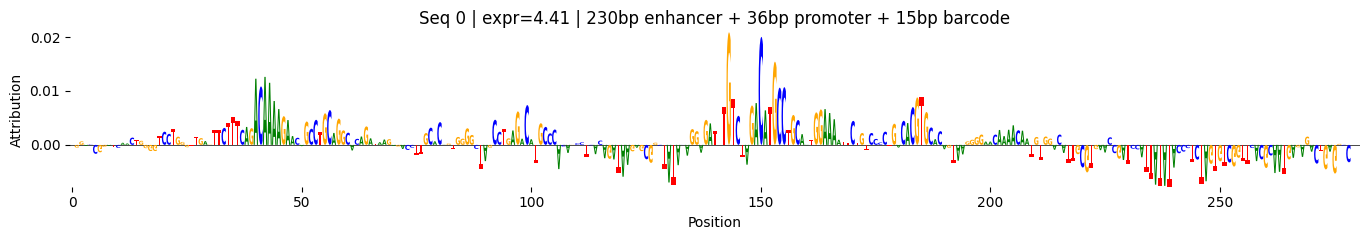

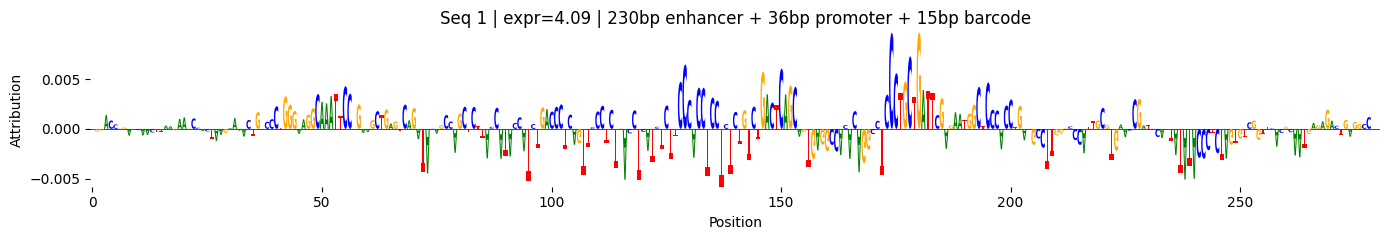

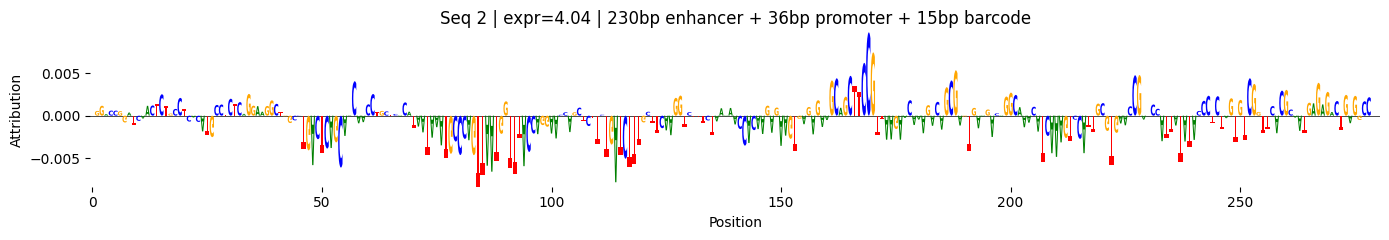

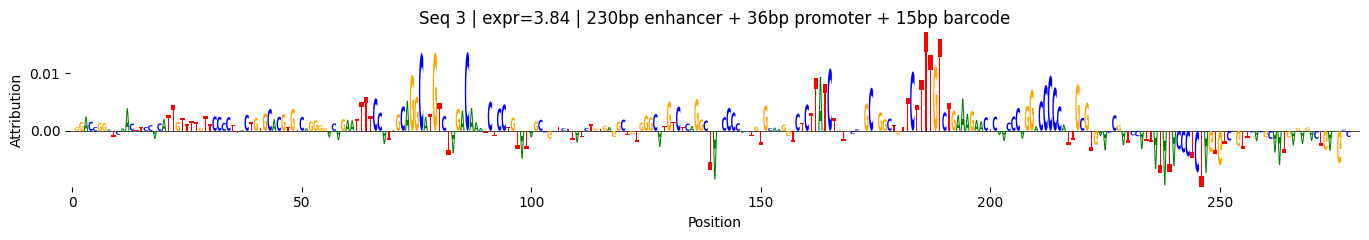

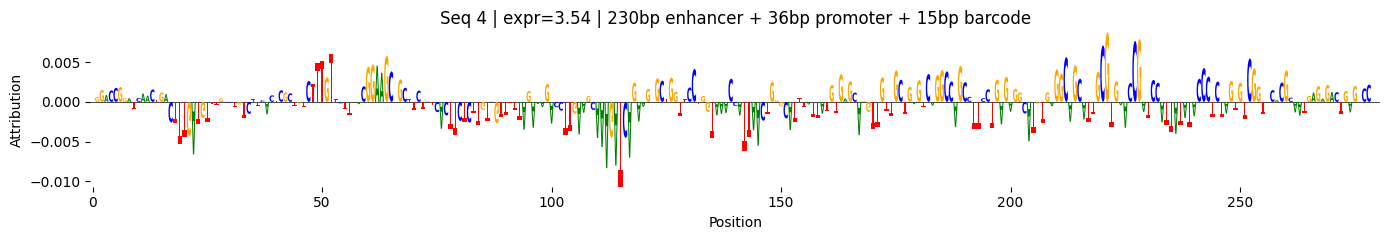

In [13]:
from tangermeme.plot import plot_logo

for i in range(len(X_attr_all)):
    expr = top_df.iloc[i]['mean_value']
    fig, ax = plt.subplots(figsize=(14, 2.5))
    plot_logo(X_attr_all[i], ax=ax)
    ax.set_title(f'Seq {i} | expr={expr:.2f} | 230bp enhancer + 36bp promoter + 15bp barcode')
    ax.set_xlabel('Position')
    ax.set_ylabel('Attribution')
    plt.tight_layout()
    plt.show()


=== Loading do0.1 (HepG2_twostep_v3_jaxmatch) ===
  Preds: [3.441236734390259, 0.7046085000038147]


  0%|          | 0/100 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([2.1779, 1.7480, 2.1279, 1.9834, 2.3022, 1.4322, 0.9752, 1.3153, 2.0347,
        1.3005, 2.2876, 1.9659, 2.4441, 1.9104, 1.9884, 1.9682, 1.6668, 1.9647,
        2.1415, 2.3269], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 20%|██        | 20/100 [00:00<00:00, 80.59it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([1.3918, 2.3928, 1.7041, 1.5610, 1.5788, 1.4420, 1.8817, 1.2485, 2.3983,
        1.9714, 1.6567, 2.1225, 2.4575, 0.8054, 2.1384, 2.7274, 1.7994, 1.7890,
        1.3968, 1.5153], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 40%|████      | 40


=== Loading do0.3 (HepG2_twostep_v3_do03) ===
  Preds: [3.1205620765686035, 0.6658239960670471]


  0%|          | 0/100 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([2.4157, 1.9746, 2.2153, 2.1313, 2.5103, 1.8392, 1.8551, 2.1284, 2.1317,
        1.8064, 2.3936, 2.3002, 2.6629, 2.2579, 2.3252, 2.1062, 2.2062, 2.6659,
        2.2599, 2.3084], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 20%|██        | 20/100 [00:00<00:00, 88.91it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([1.8893, 2.6042, 2.0636, 1.9591, 1.8199, 1.8962, 2.3108, 1.8599, 2.2457,
        2.1829, 2.2893, 2.4254, 2.6810, 0.9937, 2.1626, 2.7189, 2.2548, 2.4596,
        1.9852, 1.8984], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 40%|████      | 40


=== Loading do0.75 (HepG2_twostep_v5_do075) ===
  Preds: [3.6261744499206543, 0.8318395614624023]


  0%|          | 0/100 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.0782, 1.0673, 0.6837, 0.7585, 0.3231, 1.3155, 1.1682, 0.7549, 0.4287,
        0.7437, 0.3912, 0.7828, 0.3556, 0.7337, 0.7429, 0.9981, 0.6982, 0.1584,
        0.2857, 0.2433], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 20%|██        | 20/100 [00:00<00:00, 91.57it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([1.0815, 0.1917, 0.8963, 1.2550, 1.2929, 0.9777, 0.8478, 1.3503, 0.5656,
        0.5026, 0.3525, 0.7084, 0.1518, 0.4461, 0.5653, 0.2888, 1.0187, 0.9550,
        1.0565, 1.0644], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 40%|████      | 40


Done loading all models.
Shared y-axis limits: (np.float32(-0.033993207), np.float32(0.23030582))


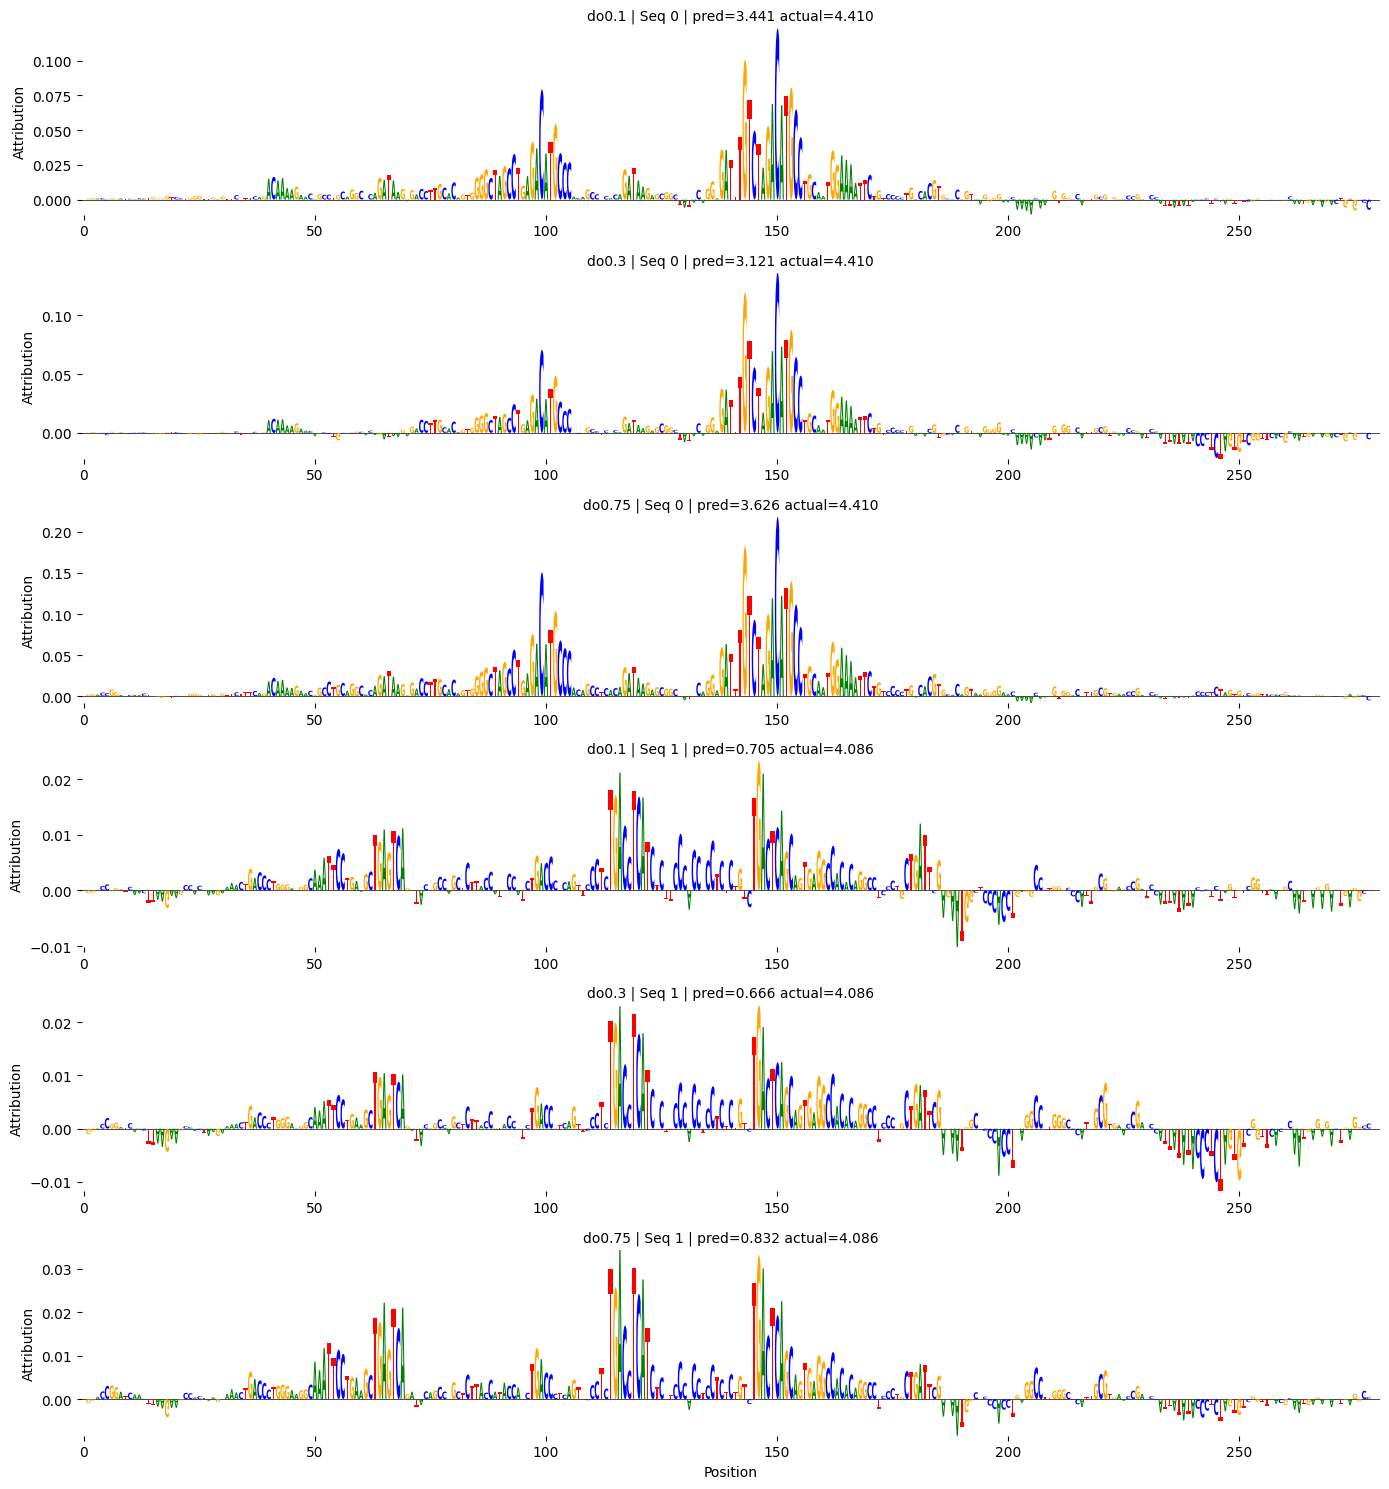

In [14]:
# === Compare attribution logos across dropout levels (HepG2) ===
# Best models: do0.1 (jaxmatch), do0.3, do0.75

HEPG2_MODELS = {
    'do0.1': 'HepG2_twostep_v3_jaxmatch',
    'do0.3': 'HepG2_twostep_v3_do03',
    'do0.75': 'HepG2_twostep_v5_do075',
}

RESULTS_DIR = os.path.join(REPO_ROOT, 'training', 'results')

# Load each model, run DeepLIFT/SHAP on seq 0 and seq 1
attrs_by_model = {}
preds_by_model = {}

for label, model_name in HEPG2_MODELS.items():
    print(f'\n=== Loading {label} ({model_name}) ===')
    ckpt_path = os.path.join(RESULTS_DIR, model_name, 'checkpoints', 'best_stage2.pt')
    
    # Reload encoder + head
    enc = AlphaGenome.from_pretrained(WEIGHTS_PATH, device='cpu')
    remove_all_heads(enc)
    
    hd = MPRAHead(
        n_positions=3, nl_size=1024, dropout=0.0,
        activation='relu', pooling_type='flatten', center_bp=256,
    )
    
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    
    wm = AlphaGenomeMPRA(enc, hd).to(device).eval()
    
    # Forward pass for predictions
    with torch.no_grad():
        p = wm(X[:2].to(device)).cpu().squeeze().tolist()
    preds_by_model[label] = p
    print(f'  Preds: {p}')
    
    # DeepLIFT/SHAP on seq 0 and seq 1
    attr = deep_lift_shap(
        wm, X[:2], target=0, n_shuffles=50, batch_size=20,
        device=str(device),
        additional_nonlinear_ops={AGCustomGELU: _nonlinear},
        warning_threshold=0.01, random_state=42, verbose=True,
    )
    attrs_by_model[label] = attr
    
    # Free GPU memory
    del wm, enc, hd, ckpt
    torch.cuda.empty_cache()

print('\nDone loading all models.')

# --- Compute shared y-axis limits across all attribution maps ---
from tangermeme.plot import plot_logo

seq_indices = [0, 1]
actuals = top_df['mean_value'].tolist()
model_labels = list(HEPG2_MODELS.keys())

global_min = float('inf')
global_max = float('-inf')
for label in model_labels:
    for si in seq_indices:
        a = attrs_by_model[label][si].numpy()
        global_min = min(global_min, a.min())
        global_max = max(global_max, a.max())

pad = (global_max - global_min) * 0.05
shared_ylim = (global_min - pad, global_max + pad)
print(f'Shared y-axis limits: {shared_ylim}')

# --- Plot comparison: 6 rows x 1 column, grouped by sequence ---
n_rows = len(seq_indices) * len(model_labels)  # 6
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 2.5 * n_rows))

for si_idx, si in enumerate(seq_indices):
    for mi, label in enumerate(model_labels):
        row = si_idx * len(model_labels) + mi
        ax = axes[row]
        plot_logo(attrs_by_model[label][si], ax=ax, ylim=shared_ylim)
        pred_val = preds_by_model[label][si]
        actual_val = actuals[si]
        ax.set_title(f'{label} | Seq {si} | pred={pred_val:.3f} actual={actual_val:.3f}', fontsize=10)
        if row == n_rows - 1:
            ax.set_xlabel('Position')
        ax.set_ylabel('Attribution')

plt.tight_layout()
plt.show()